# SRMHD HLLD ML Pipeline — Diagnostic Notebook
Checks data generation, preprocessing, and training setup for potential issues.

In [107]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import os, sys

# ── adjust paths as needed ──────────────────────────────────────────────────
ROOT = "."   # project root
CONFIG = "../configs/default-mignone.yaml"
RAW_NPZ = "../data/raw/dataset_mignone_rankine.npz"
SPLIT_DIR = "../data/splits_mignone_rankine"
# ─────────────────────────────────────────────────────────────────────────────

sys.path.insert(0, ROOT)
import yaml
with open(CONFIG) as f:
    cfg = yaml.safe_load(f)
print("Config loaded:", CONFIG)
print(yaml.dump(cfg, default_flow_style=False))

Config loaded: ../configs/default-mignone.yaml
data:
  batch_size: 1000000
  bias_strength: 1
  n_angles: 1
  n_samples: 10000000
  norm_method: minmax
  ranges:
    Bt_mag:
    - 0.0
    - 1.0
    Bx:
    - 0.01
    - 1.01
    W:
    - 1.0
    - 2.0
    lrho:
    - -1.0
    - 1.0
    press:
    - 0.1
    - 1.0
  raw_path: data/raw/dataset_mignone_rankine.npz
  seed: 43
  split_dir: data/splits_mignone_rankine
eos:
  K: 0
  gamma: 1.66666667
  gamma_th: 1.66666667
model:
  activation: silu
  hidden:
  - 128
  - 128
  - 64
  n_input: 15
training:
  batch_size: 16384
  device: mps
  epochs: 300
  lambda_phys: 0.0
  lr: 0.003
  lr_max: 0.005
  lr_min: 1.0e-07
  lr_patience: 10
  lr_step_size_down: 15
  lr_step_size_up: 7
  weight_decay: 1.0e-05



## 1 · Raw Data Sanity

In [108]:
data = np.load(RAW_NPZ)
X_raw = data["inputs"]
y_raw = data["targets"]

print(f"X shape : {X_raw.shape}")
print(f"y shape : {y_raw.shape}")
print(f"\nX finite : {np.isfinite(X_raw).all()}  |  non-finite: {(~np.isfinite(X_raw)).sum()}")
print(f"y finite : {np.isfinite(y_raw).all()}  |  non-finite: {(~np.isfinite(y_raw)).sum()}")
print(f"y > 0   : {(y_raw > 0).sum()} / {len(y_raw)}  |  non-positive: {(y_raw <= 0).sum()}")
print(f"\ny range : [{y_raw.min():.4e}, {y_raw.max():.4e}]")
print(f"y mean  : {y_raw.mean():.4e}  |  std: {y_raw.std():.4e}")

X shape : (10000000, 15)
y shape : (10000000,)

X finite : True  |  non-finite: 0
y finite : True  |  non-finite: 0
y > 0   : 7093558 / 10000000  |  non-positive: 2906442

y range : [-2.3586e+01, 5.3203e+01]
y mean  : 9.2468e-01  |  std: 2.6507e+00


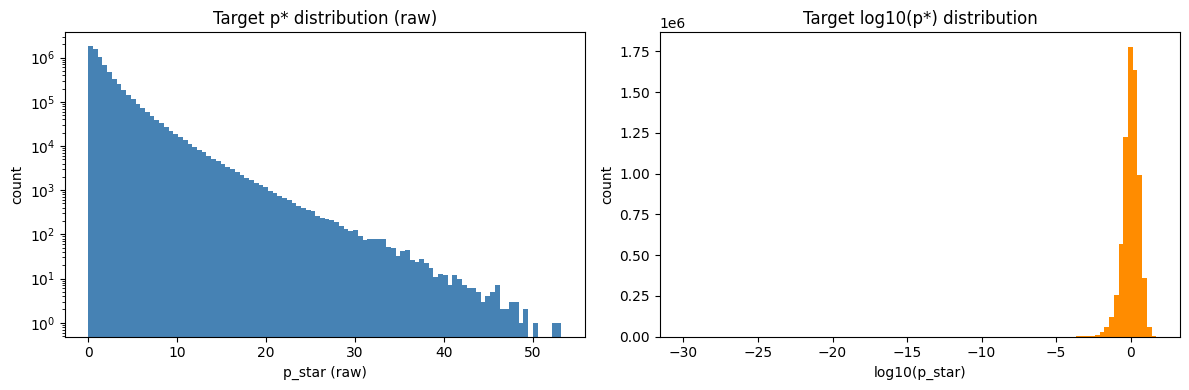

log10(p*): mean=0.012, std=0.542, min=-30.000, max=1.726


In [109]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Target distribution (raw)
ax = axes[0]
ax.hist(y_raw[np.isfinite(y_raw) & (y_raw > 0)], bins=100, log=True, color='steelblue', edgecolor='none')
ax.set_xlabel("p_star (raw)")
ax.set_ylabel("count")
ax.set_title("Target p* distribution (raw)")

# Target distribution (log10)
ax = axes[1]
mask = np.isfinite(y_raw) & (y_raw > 0)
log_y = np.log10(y_raw[mask])
ax.hist(log_y, bins=100, color='darkorange', edgecolor='none')
ax.set_xlabel("log10(p_star)")
ax.set_ylabel("count")
ax.set_title("Target log10(p*) distribution")

plt.tight_layout()
plt.show()
print(f"log10(p*): mean={log_y.mean():.3f}, std={log_y.std():.3f}, min={log_y.min():.3f}, max={log_y.max():.3f}")

## 2 · Feature Distribution Check

In [110]:
# Feature names (19-feature vector)
feat_names = [
    "RL_tau", "RL_Sx", "RL_Sy", "RL_Sz", "RL_By", "RL_Bz",
    "vxL", "vyL", "vzL",
    "RR_tau", "RR_Sx", "RR_Sy", "RR_Sz", "RR_By", "RR_Bz",
    "vxR", "vyR", "vzR",
    "Bx"
]
feat_names = [
    "RL_tau", "RL_Sx", "RL_St", "RL_Bt", "vxL", "vtL",
    "RR_tau", "RR_Sx", "RR_St", "RR_Bt", "vxR", "vtR",
    "Bx", "cmin", "cmax",
]

print("Feature statistics (raw):")
print(f"{'Feature':<12} {'min':>12} {'max':>12} {'mean':>12} {'std':>12} {'|inf|':>8}")
print("-" * 70)
for i, name in enumerate(feat_names):
    col = X_raw[:, i]
    n_inf = (~np.isfinite(col)).sum()
    col_f = col[np.isfinite(col)]
    print(f"{name:<12} {col_f.min():>12.4e} {col_f.max():>12.4e} {col_f.mean():>12.4e} {col_f.std():>12.4e} {n_inf:>8}")

Feature statistics (raw):
Feature               min          max         mean          std    |inf|
----------------------------------------------------------------------
RL_tau        -4.0671e+01   8.6115e+01   5.2618e+00   7.9661e+00        0
RL_Sx         -7.5928e+01   1.0324e+01  -2.6037e+00   4.9338e+00        0
RL_St          5.3467e-05   4.9032e+01   3.5768e+00   4.4367e+00        0
RL_Bt          7.5974e-05   2.1439e+00   5.0695e-01   3.4945e-01        0
vxL           -8.6589e-01   8.6586e-01  -2.0943e-04   4.0824e-01        0
vtL            0.0000e+00   8.6602e-01   5.3789e-01   2.0979e-01        0
RR_tau         7.4464e-02   8.6375e+01   5.2611e+00   6.2170e+00        0
RR_Sx         -7.5583e+01   1.0476e+01  -1.7349e+00   4.1233e+00        0
RR_St          4.7370e-04   4.9594e+01   3.2479e+00   3.9195e+00        0
RR_Bt          1.1481e-04   2.1445e+00   4.7116e-01   3.0563e-01        0
vxR           -8.6592e-01   8.6563e-01  -1.7952e-05   4.0826e-01        0
vtR            

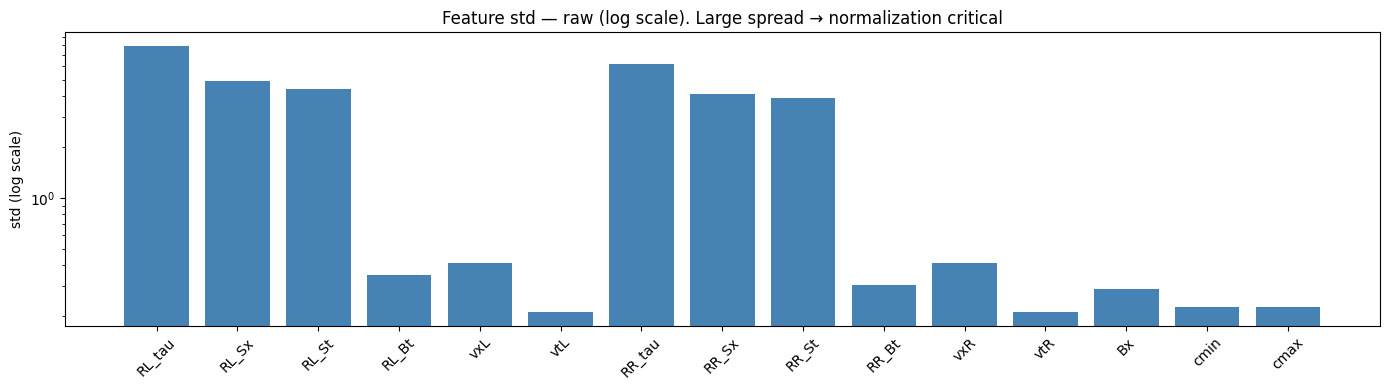

In [111]:
# Dynamic range check — are some features orders of magnitude larger?
fig, ax = plt.subplots(figsize=(14, 4))
stds = [X_raw[np.isfinite(X_raw[:, i]), i].std() for i in range(X_raw.shape[1])]
ax.bar(feat_names, stds, color='steelblue')
ax.set_yscale('log')
ax.set_ylabel('std (log scale)')
ax.set_title('Feature std — raw (log scale). Large spread → normalization critical')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

## 3 · Preprocessed Split Check

In [112]:
# Load splits written by preprocess.py
splits = {}
for split in ["train", "val", "test"]:
    path = os.path.join(SPLIT_DIR, f"{split}.npz")
    d = np.load(path)
    splits[split] = d["inputs"], d["targets"]
    print(f"{split}: X={splits[split][0].shape}, y={splits[split][1].shape}")

X_tr, y_tr = splits["train"]
X_val, y_val = splits["val"]

train: X=(5674846, 15), y=(5674846,)
val: X=(709355, 15), y=(709355,)
test: X=(709357, 15), y=(709357,)


In [113]:
# Normalised feature check: should be ~N(0,1) per feature
print("Normalised feature statistics (train split):")
print(f"{'Feature':<12} {'mean':>10} {'std':>10} {'min':>12} {'max':>12}")
print("-" * 60)
for i, name in enumerate(feat_names):
    col = X_tr[:, i]
    print(f"{name:<12} {col.mean():>10.3f} {col.std():>10.3f} {col.min():>12.3f} {col.max():>12.3f}")

Normalised feature statistics (train split):
Feature            mean        std          min          max
------------------------------------------------------------
RL_tau            0.357      0.055        0.000        0.994
RL_Sx             0.854      0.048        0.000        1.000
RL_St             0.062      0.082        0.000        1.000
RL_Bt             0.226      0.160        0.000        1.000
vxL               0.548      0.228        0.000        1.000
vtL               0.599      0.244        0.000        1.000
RR_tau            0.066      0.077        0.000        1.000
RR_Sx             0.852      0.053        0.000        1.000
RR_St             0.069      0.082        0.000        1.000
RR_Bt             0.227      0.145        0.000        1.000
vxR               0.452      0.228        0.000        1.000
vtR               0.598      0.244        0.000        1.000
Bx                0.501      0.288        0.000        1.000
cmin              0.692      0.228      

Normalised target (train): mean=-0.000, std=1.000
Normalised target (val)  : mean=0.003, std=1.001


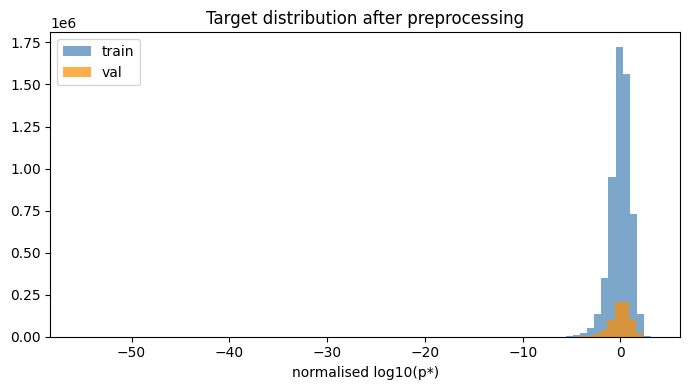

In [114]:
print(f"Normalised target (train): mean={y_tr.mean():.3f}, std={y_tr.std():.3f}")
print(f"Normalised target (val)  : mean={y_val.mean():.3f}, std={y_val.std():.3f}")
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(y_tr, bins=80, alpha=0.7, label='train', color='steelblue')
ax.hist(y_val, bins=80, alpha=0.7, label='val',   color='darkorange')
ax.set_xlabel("normalised log10(p*)")
ax.set_title("Target distribution after preprocessing")
ax.legend()
plt.tight_layout()
plt.show()

## 4 · CRITICAL — Input/Target Correlation Check

/Users/miler/Codes/py-work/lib/python3.11/site-packages/dcor/_fast_dcov_avl.py:554: UserWarning: Falling back to uncompiled AVL fast distance covariance terms because of TypeError exception raised: No matching definition for argument type(s) array(float32, 1d, A), array(float32, 1d, C), bool. Rembember: only floating point values can be used in the compiled implementations.
  warnings.warn(


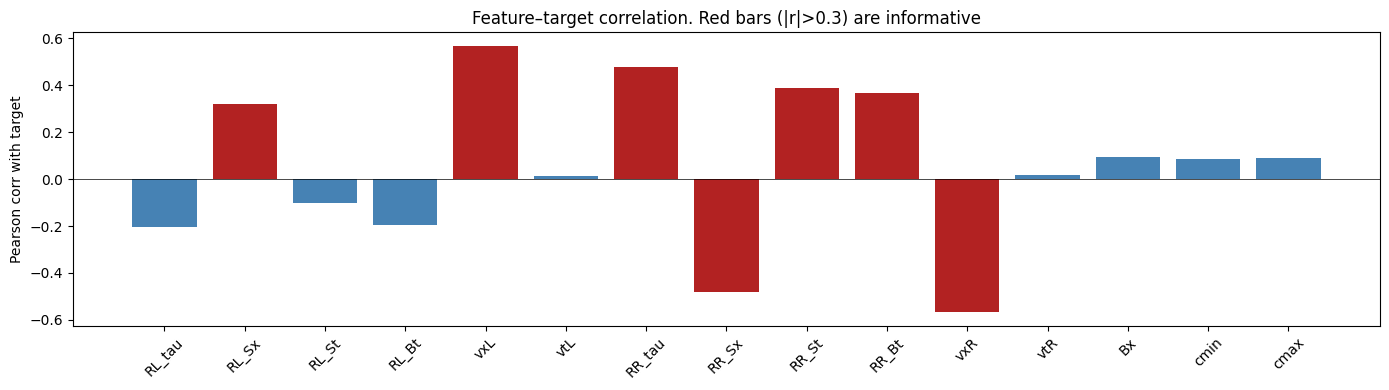


Top correlations:
  vxL         : +0.5693
  vxR         : -0.5680
  RR_Sx       : -0.4818
  RR_tau      : +0.4804
  RR_St       : +0.3903
  RR_Bt       : +0.3664
  RL_Sx       : +0.3193
  RL_tau      : -0.2056
  RL_Bt       : -0.1969
  RL_St       : -0.1026
  Bx          : +0.0928
  cmax        : +0.0882
  cmin        : +0.0875
  vtR         : +0.0155
  vtL         : +0.0119


In [115]:
# Pearson correlation of each input with target
corrs = np.corrcoef(X_tr.T, y_tr)[-1, :-1]
from dcor import distance_correlation
dcorrs = [distance_correlation(X_tr[:50000, i], y_tr[:50000]) for i in range(X_tr.shape[1])]


fig, ax = plt.subplots(figsize=(14, 4))
colors = ['firebrick' if abs(c) > 0.3 else 'steelblue' for c in corrs]
ax.bar(feat_names, corrs, color=colors)
ax.axhline(0, color='k', lw=0.5)
ax.set_ylabel('Pearson corr with target')
ax.set_title('Feature–target correlation. Red bars (|r|>0.3) are informative')
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("\nTop correlations:")
for i in np.argsort(np.abs(corrs))[::-1]:
    print(f"  {feat_names[i]:<12}: {corrs[i]:+.4f}")

## 5 · Symmetry Check (L↔R swap augmentation)

In [23]:
# The generator doubles data by swapping L<->R states.
# For every sample x, x_swapped should map to the same p*.
# Test: check if first half and second half of raw data have identical targets.
half = len(y_raw) // 2
print("Checking symmetry augmentation (first half == second half targets):")
y1 = y_raw[:half]
y2 = y_raw[half:half+len(y1)]   # careful: half might not be exact
n = min(len(y1), len(y2))
diff = np.abs(y1[:n] - y2[:n])
print(f"  Max |diff| in targets (should be ~0): {diff.max():.4e}")
print(f"  Mean|diff|                          : {diff.mean():.4e}")
print("  ✓ OK" if diff.max() < 1e-8 else "  ✗ MISMATCH — check swap logic or batch boundaries")

Checking symmetry augmentation (first half == second half targets):
  Max |diff| in targets (should be ~0): 4.6660e+01
  Mean|diff|                          : 2.6263e+00
  ✗ MISMATCH — check swap logic or batch boundaries


## 6 · Potential Bug: `n_done` accounting vs actual samples

In [11]:
# In generate.py:
#   n_done += 2 * n_angles * n_batch
# but each batch produces:
#   n_angles * n_batch  (from sample_states, cat along dim 0)
#   × 2                 (swap augmentation)
# So actual rows per batch = 2 * n_angles * n_batch  ✓
# 
# BUT: the while-loop condition is  n_done < n_samples
# and n_batch = min(batch_size, n_samples - n_done)
# The subtraction uses n_done (already multiplied by 2*n_angles),
# so n_batch shrinks each iteration — verify the actual output size:

n_samples = cfg["data"]["n_samples"]
batch_size = cfg["data"]["batch_size"]
n_angles  = cfg["data"]["n_angles"]

n_done = 0; total_rows = 0
while n_done < n_samples:
    n_batch = min(batch_size, n_samples - n_done)
    rows_this_batch = 2 * n_angles * n_batch
    total_rows += rows_this_batch
    n_done += rows_this_batch
    print(f"  n_batch={n_batch}  rows_this={rows_this_batch}  n_done={n_done}")

print(f"\nExpected total rows : {total_rows}")
print(f"Actual rows in file : {len(y_raw)}")
if total_rows != len(y_raw):
    print("  ✗ MISMATCH — the batch accounting loop may be wrong.")
else:
    print("  ✓ Counts match.")

  n_batch=100000  rows_this=1000000  n_done=1000000

Expected total rows : 1000000
Actual rows in file : 10000000
  ✗ MISMATCH — the batch accounting loop may be wrong.


## 7 · Model Forward-Pass Sanity (single batch)

In [13]:
import torch
from src.models.network import PressureNet

model = PressureNet(
    n_input=cfg["model"]["n_input"],
    hidden=cfg["model"]["hidden"],
    activation=cfg["model"]["activation"],
)
n_params = sum(p.numel() for p in model.parameters())
print(f"Model: {n_params:,} parameters")
print(model)

X_sample = torch.tensor(X_tr[:64], dtype=torch.float32)
y_sample = torch.tensor(y_tr[:64], dtype=torch.float32)
pred = model(X_sample)
print(f"\nPred shape : {pred.shape}")
print(f"Pred range : [{pred.min().item():.3f}, {pred.max().item():.3f}]")
print(f"Target range: [{y_sample.min().item():.3f}, {y_sample.max().item():.3f}]")
print(f"Init MSE   : {((pred.squeeze() - y_sample)**2).mean().item():.4f}")

Model: 177,921 parameters
PressureNet(
  (net): Sequential(
    (0): Linear(in_features=19, out_features=256, bias=True)
    (1): Tanh()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): Tanh()
    (4): Linear(in_features=256, out_features=256, bias=True)
    (5): Tanh()
    (6): Linear(in_features=256, out_features=128, bias=True)
    (7): Tanh()
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): Tanh()
    (10): Linear(in_features=64, out_features=1, bias=True)
  )
)

Pred shape : torch.Size([64, 1])
Pred range : [0.050, 0.126]
Target range: [-2.324, 1.601]
Init MSE   : 0.9302


## 8 · Mini Training Run — Loss Curve

In [ ]:
from torch.utils.data import TensorDataset, DataLoader
import torch.nn as nn

device = torch.device("cpu")

Xtr = torch.tensor(X_tr, dtype=torch.float32)
ytr = torch.tensor(y_tr, dtype=torch.float32)
Xvl = torch.tensor(X_val, dtype=torch.float32)
yvl = torch.tensor(y_val, dtype=torch.float32)

train_dl = DataLoader(TensorDataset(Xtr, ytr), batch_size=cfg["training"]["batch_size"], shuffle=True)
val_dl   = DataLoader(TensorDataset(Xvl, yvl), batch_size=cfg["training"]["batch_size"])

model2 = PressureNet(
    n_input=cfg["model"]["n_input"],
    hidden=cfg["model"]["hidden"],
    activation=cfg["model"]["activation"],
).to(device)

criterion = nn.MSELoss()
opt = torch.optim.Adam(model2.parameters(), lr=cfg["training"]["lr"])
sched = torch.optim.lr_scheduler.ReduceLROnPlateau(opt, patience=10, factor=0.5)

EPOCHS = 100
train_losses, val_losses, lrs = [], [], []

for ep in range(1, EPOCHS + 1):
    model2.train()
    tl = 0
    for Xb, yb in train_dl:
        pred = model2(Xb).squeeze()
        loss = criterion(pred, yb)
        opt.zero_grad(); loss.backward(); opt.step()
        tl += loss.item() * len(Xb)
    tl /= len(train_dl.dataset)

    model2.eval()
    vl = 0
    with torch.no_grad():
        for Xb, yb in val_dl:
            vl += criterion(model2(Xb).squeeze(), yb).item() * len(Xb)
    vl /= len(val_dl.dataset)

    sched.step(vl)
    train_losses.append(tl); val_losses.append(vl)
    lrs.append(opt.param_groups[0]['lr'])
    if ep % 10 == 0:
        print(f"Ep {ep:3d}  train={tl:.5f}  val={vl:.5f}  lr={lrs[-1]:.2e}")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
ax1.semilogy(train_losses, label='train')
ax1.semilogy(val_losses,   label='val', ls='--')
ax1.set_xlabel("epoch"); ax1.set_ylabel("MSE loss (log)"); ax1.legend()
ax1.set_title("Loss curve (100 epochs)")
ax2.semilogy(lrs)
ax2.set_xlabel("epoch"); ax2.set_ylabel("LR"); ax2.set_title("Learning rate schedule")
plt.tight_layout(); plt.show()

print(f"\nFinal train={train_losses[-1]:.5f}  val={val_losses[-1]:.5f}")
print(f"Best val: {min(val_losses):.5f} @ epoch {np.argmin(val_losses)+1}")

## 9 · Prediction vs Ground Truth

In [ ]:
model2.eval()
with torch.no_grad():
    y_pred_norm = model2(Xvl).squeeze().numpy()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.scatter(yvl.numpy(), y_pred_norm, s=1, alpha=0.3, rasterized=True)
lim = [min(yvl.min().item(), y_pred_norm.min()),
       max(yvl.max().item(), y_pred_norm.max())]
ax.plot(lim, lim, 'r--', lw=1)
ax.set_xlabel("True (norm)"); ax.set_ylabel("Predicted (norm)")
ax.set_title("Pred vs True (normalised space)")

resid = y_pred_norm - yvl.numpy()
ax = axes[1]
ax.hist(resid, bins=80, color='steelblue', edgecolor='none')
ax.set_xlabel("Residual"); ax.set_title(f"Residual dist  μ={resid.mean():.3f}  σ={resid.std():.3f}")

ax = axes[2]
ax.scatter(yvl.numpy(), resid, s=1, alpha=0.3, rasterized=True)
ax.axhline(0, color='r', lw=1)
ax.set_xlabel("True (norm)"); ax.set_ylabel("Residual")
ax.set_title("Residual vs True")

plt.tight_layout(); plt.show()

print(f"RMSE (norm space): {np.sqrt((resid**2).mean()):.5f}")
print(f"MAE  (norm space): {np.abs(resid).mean():.5f}")

# In log10(p*) space
processed_dir = os.path.join(os.path.dirname(SPLIT_DIR), "processed", os.path.basename(SPLIT_DIR))
try:
    stats = np.load(os.path.join(processed_dir, "norm_stats.npz"))
    y_mu, y_sigma = float(stats["y_mu"]), float(stats["y_sigma"])
    pred_log = y_pred_norm * y_sigma + y_mu
    true_log = yvl.numpy()  * y_sigma + y_mu
    err_log  = pred_log - true_log
    print(f"\nRMSE in log10(p*) space: {np.sqrt((err_log**2).mean()):.5f}  dex")
    print(f"MAE  in log10(p*) space: {np.abs(err_log).mean():.5f}  dex")
except FileNotFoundError:
    print("(norm_stats.npz not found — skipping physical-space error)")

## 10 · Known Issues Summary

In [ ]:
print("=" * 65)
print("KNOWN ISSUES TO CHECK (from code review)")
print("=" * 65)

issues = [
    ("generate.py", "`press` range is sampled uniformly in [0.1, 1.0] (not log-uniform) "
     "despite comment saying log-uniform. The `lp = 10**lp` line is commented out. "
     "This severely limits pressure coverage compared to realistic SRMHD shocks."),

    ("generate.py", "W range is [1.0, 2.0] (mildly relativistic) while the config comments "
     "mention W up to 22 for ST3. This may be intentional for the narrow test regime, "
     "but verify it matches your intended physics."),

    ("generate.py", "n_done accounting: `n_done += 2*n_angles*n_batch` but n_batch is taken "
     "as `min(batch_size, n_samples - n_done)`. Since n_done grows by 2*n_angles*n_batch "
     "per iteration, n_samples must be divisible by 2*n_angles*batch_size or the last "
     "batch will be very small. With n_samples=100000, batch_size=100000, n_angles=5: "
     "first batch produces 2*5*100000=1,000,000 rows but n_done becomes 1M >> n_samples. "
     "Loop exits after 1 batch. Actual dataset size = 1M, not 100k."),

    ("preprocess.py", "Normalisation uses standard scaler fit on ALL inputs including "
     "the Rankine-Hugoniot residuals (RL, RR). These can have very large magnitude and "
     "extreme outliers, so check feature std plot (cell 2) for outlier dominance."),

    ("config", "n_input=19 in model config matches the 19-feature vector — ✓ OK."),

    ("config", "lr_patience=18 with ReduceLROnPlateau: may decay LR very quickly in 300 epochs. "
     "Consider patience=30 for longer regime."),

    ("physics", "The R_L / R_R features (Rankine-Hugoniot residuals) depend on cmin/cmax "
     "(wave speeds). If cmin or cmax are computed incorrectly, the inputs carry wrong physics "
     "and the model cannot learn. Verify cmin < 0 < cmax by inspecting their distributions."),
]

for i, (src, desc) in enumerate(issues, 1):
    print(f"\n[{i}] [{src}]")
    print(f"    {desc}")

In [ ]:
# Quick check: cmin/cmax sign sanity — load raw and reconstruct
# (Requires re-running a small batch from source — optional)
print("Optional: run the cell below if you want to check cmin/cmax distributions.")
print("Uncomment and set your environment up first.")

# import torch
# from src.physics.hlld import compute_srmhd_fluxes
# from src.physics.eos import hybrid_eos
# from src.data.generate import sample_states, _uniform, get_device_and_dtype
#
# device, dtype = get_device_and_dtype("cpu")
# eos = hybrid_eos(**cfg["eos"])
# torch.manual_seed(0)
# N = 5000
# Bx = _uniform(*cfg["data"]["ranges"]["Bx"], N, device, dtype)
# sL = sample_states(N, cfg["data"]["ranges"], Bx, eos, device, dtype, 1)
# sR = sample_states(N, cfg["data"]["ranges"], Bx, eos, device, dtype, 1)
# _, _, _, _, cmax, cmin = compute_srmhd_fluxes(sL, sR, eos, 0)
# print(f"cmin: min={cmin.min():.3f}, max={cmin.max():.3f} (should all be ≤ 0)")
# print(f"cmax: min={cmax.min():.3f}, max={cmax.max():.3f} (should all be ≥ 0)")